In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/shopping_trends.csv")
X = pd.read_csv("../data/clustering_features.csv")
reference_labels = np.load("../data/reference_labels.npy")

profile = X.copy()
profile["Cluster"] = reference_labels

In [3]:
dashboard_profiles = (
    profile.groupby("Cluster")
    .agg(
        Customers=("Cluster", "size"),
        Avg_Age=("Age", "mean"),
        Avg_Purchase=("Purchase Amount (USD)", "mean"),
        Avg_Previous_Purchases=("Previous Purchases", "mean"),
        Avg_Purchase_Frequency=("Purchase Frequency", "mean"),
        Subscription_Rate=("Is_Subscribed", "mean")
    )
    .round(2)
)

dashboard_profiles

,Customers,Avg_Age,Avg_Purchase,Avg_Previous_Purchases,Avg_Purchase_Frequency,Subscription_Rate
Cluster,,,,,,
0,1986,44.20,58.44,23.89,4.37,0.26
1,1914,43.93,61.14,26.87,31.07,0.28


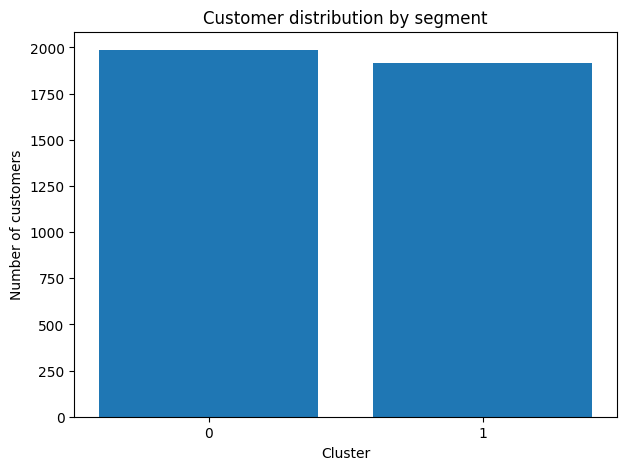

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    dashboard_profiles.index.astype(str),
    dashboard_profiles["Customers"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of customers")
plt.title("Customer distribution by segment")

plt.show()

The customer base is almost evenly split between the two segments, with approximately 51% of customers in Cluster 0 and 49% in Cluster 1.

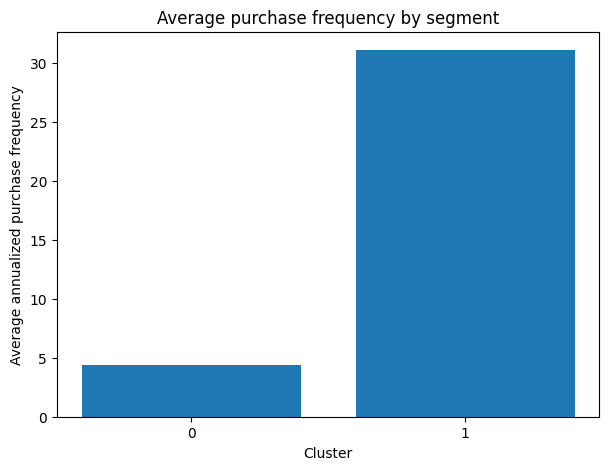

In [5]:
plt.figure(figsize=(7, 5))

plt.bar(
    dashboard_profiles.index.astype(str),
    dashboard_profiles["Avg_Purchase_Frequency"]
)

plt.xlabel("Cluster")
plt.ylabel("Average annualized purchase frequency")
plt.title("Average purchase frequency by segment")

plt.show()

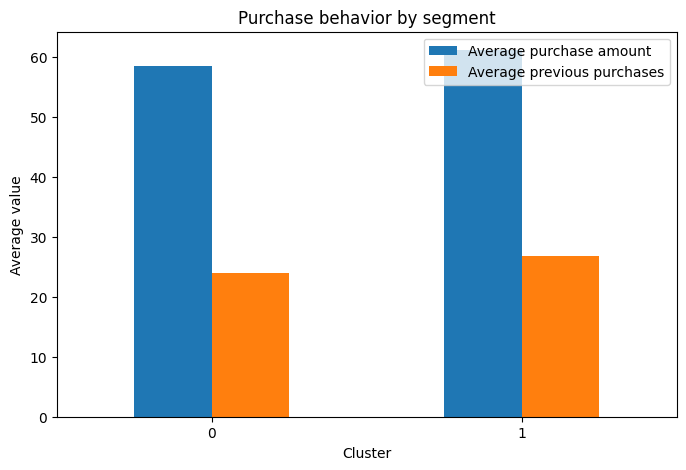

In [6]:
comparison_metrics = dashboard_profiles[
    [
        "Avg_Purchase",
        "Avg_Previous_Purchases"
    ]
].copy()

comparison_metrics.index = comparison_metrics.index.astype(str)

comparison_metrics.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Average value")
plt.title("Purchase behavior by segment")
plt.legend([
    "Average purchase amount",
    "Average previous purchases"
])

plt.xticks(rotation=0)
plt.show()

In [7]:
profile_metrics = dashboard_profiles[
    [
        "Avg_Purchase",
        "Avg_Previous_Purchases",
        "Avg_Purchase_Frequency"
    ]
].copy()

profile_metrics = profile_metrics.T

profile_normalized = (
    profile_metrics - profile_metrics.min(axis=1).values[:, None]
) / (
    profile_metrics.max(axis=1).values[:, None]
    - profile_metrics.min(axis=1).values[:, None]
)

profile_normalized.columns = [
    f"Cluster {cluster}"
    for cluster in profile_normalized.columns
]

profile_normalized

,Cluster 0,Cluster 1
Avg_Purchase,0.0,1.0
Avg_Previous_Purchases,0.0,1.0
Avg_Purchase_Frequency,0.0,1.0


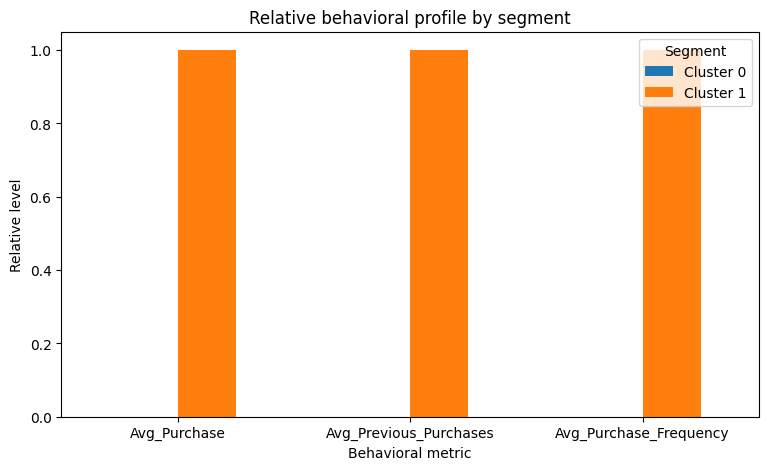

In [8]:
profile_normalized.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Behavioral metric")
plt.ylabel("Relative level")
plt.title("Relative behavioral profile by segment")

plt.xticks(rotation=0)
plt.legend(title="Segment")

plt.show()

In [9]:
total_customers = len(profile)
n_segments = profile["Cluster"].nunique()

cluster_0_size = dashboard_profiles.loc[0, "Customers"]
cluster_1_size = dashboard_profiles.loc[1, "Customers"]

cluster_0_share = cluster_0_size / total_customers * 100
cluster_1_share = cluster_1_size / total_customers * 100

print("Total customers:", total_customers)
print("Number of segments:", n_segments)
print("Cluster 0:", round(cluster_0_share, 1), "%")
print("Cluster 1:", round(cluster_1_share, 1), "%")

Total customers: 3900
Number of segments: 2
Cluster 0: 50.9 %
Cluster 1: 49.1 %


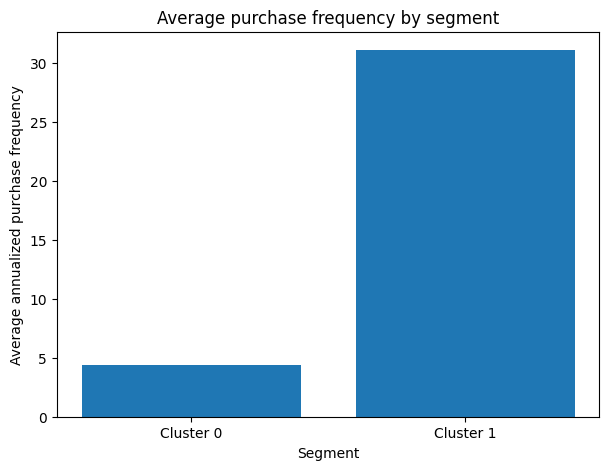

In [11]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Cluster 0", "Cluster 1"],
    [
        dashboard_profiles.loc[0, "Avg_Purchase_Frequency"],
        dashboard_profiles.loc[1, "Avg_Purchase_Frequency"]
    ]
)

plt.xlabel("Segment")
plt.ylabel("Average annualized purchase frequency")
plt.title("Average purchase frequency by segment")

plt.show()

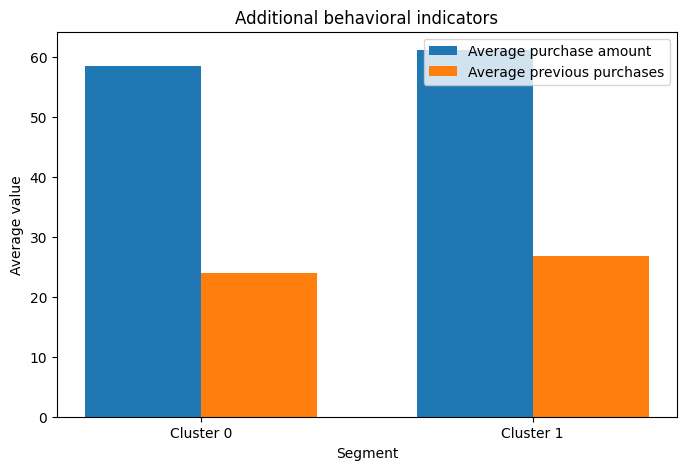

In [12]:
plt.figure(figsize=(8, 5))

x = np.arange(2)
width = 0.35

purchase_values = [
    dashboard_profiles.loc[0, "Avg_Purchase"],
    dashboard_profiles.loc[1, "Avg_Purchase"]
]

previous_values = [
    dashboard_profiles.loc[0, "Avg_Previous_Purchases"],
    dashboard_profiles.loc[1, "Avg_Previous_Purchases"]
]

plt.bar(
    x - width / 2,
    purchase_values,
    width,
    label="Average purchase amount"
)

plt.bar(
    x + width / 2,
    previous_values,
    width,
    label="Average previous purchases"
)

plt.xticks(x, ["Cluster 0", "Cluster 1"])
plt.xlabel("Segment")
plt.ylabel("Average value")
plt.title("Additional behavioral indicators")
plt.legend()

plt.show()

In [13]:
print("=" * 50)
print("       CUSTOMER INTELLIGENCE DASHBOARD")
print("=" * 50)

print(f"Total customers: {total_customers:,}")
print(f"Number of segments: {n_segments}")

print(
    f"Cluster 0: {cluster_0_size:,} customers "
    f"({cluster_0_share:.1f}%)"
)

print(
    f"Cluster 1: {cluster_1_size:,} customers "
    f"({cluster_1_share:.1f}%)"
)

print(
    f"Cluster 0 average frequency: "
    f"{dashboard_profiles.loc[0, 'Avg_Purchase_Frequency']:.2f}"
)

print(
    f"Cluster 1 average frequency: "
    f"{dashboard_profiles.loc[1, 'Avg_Purchase_Frequency']:.2f}"
)

       CUSTOMER INTELLIGENCE DASHBOARD
Total customers: 3,900
Number of segments: 2
Cluster 0: 1,986 customers (50.9%)
Cluster 1: 1,914 customers (49.1%)
Cluster 0 average frequency: 4.37
Cluster 1 average frequency: 31.07


In [14]:
business_summary = {
    "Main finding": (
        "The segmentation primarily differentiates customers "
        "by purchase intensity."
    ),
    
    "Lower intensity segment": (
        "Cluster 0 shows substantially lower purchase frequency."
    ),
    
    "Higher intensity segment": (
        "Cluster 1 shows substantially higher purchase frequency."
    ),
    
    "Secondary differences": (
        "Previous purchases and purchase amount are only moderately higher "
        "in Cluster 1."
    ),
    
    "Recommended use": (
        "Use the segments to support customer prioritization "
        "and targeted engagement strategies."
    ),
    
    "Important limitation": (
        "The segmentation is descriptive and does not predict future "
        "customer behavior or establish causality."
    )
}

for key, value in business_summary.items():
    print(f"{key}:")
    print(value)
    print()
    

Main finding:
The segmentation primarily differentiates customers by purchase intensity.

Lower intensity segment:
Cluster 0 shows substantially lower purchase frequency.

Higher intensity segment:
Cluster 1 shows substantially higher purchase frequency.

Secondary differences:
Previous purchases and purchase amount are only moderately higher in Cluster 1.

Recommended use:
Use the segments to support customer prioritization and targeted engagement strategies.

Important limitation:
The segmentation is descriptive and does not predict future customer behavior or establish causality.



In [15]:
import sys

sys.path.append("..")

from src.customer_features import CustomerFeatureTransformer

transformer = CustomerFeatureTransformer()

print(transformer.final_features)

['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'Purchase Frequency', 'Is_Subscribed', 'Log_Annual_Spend', 'Log_Purchase_Engagement']
